In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/processed/base_de_dados_completo_eda.csv')

## Exploração inicial

In [4]:
df.head()

,data_referencia,ra,fase,turma,nome,ano_nasc,idade_22,gênero,ano_ingresso,instituição_de_ensino,...,ing,fase_ideal.1,destaque_ipv_1,inde_2024,pedra_2024,avaliador5,avaliador6,escola,ativo/inativo,ativo/inativo_1
0,2022-01-01,RA-1,7,A,Aluno-1,2003.0,19.0,Menina,2016,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01,RA-61,5,B,Aluno-61,2007.0,15.0,Menino,2021,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-01,RA-610,1,L,Aluno-610,2013.0,9.0,Menina,2022,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01,RA-611,1,M,Aluno-611,2010.0,12.0,Menino,2021,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-01,RA-612,1,M,Aluno-612,2012.0,10.0,Menina,2021,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.query('ra == "RA-1000"')

,data_referencia,ra,fase,turma,nome,ano_nasc,idade_22,gênero,ano_ingresso,instituição_de_ensino,...,ing,fase_ideal.1,destaque_ipv_1,inde_2024,pedra_2024,avaliador5,avaliador6,escola,ativo/inativo,ativo/inativo_1
1529,2023-01-01,RA-1000,ALFA,ALFA U - G2/G3,NaN,NaN,NaN,Feminino,2023,Pública,...,NaN,ALFA (1° e 2° ano),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2644,2024-01-01,RA-1000,1N,1N,NaN,NaN,NaN,Feminino,2023,Pública,...,NaN,Fase 1 (3° e 4° ano),NaN,8.364790909100002,Topázio,NaN,NaN,EE Helio Luiz Dobrochinski Prof,Cursando,Cursando


In [6]:
df_pivot = (
    df
    .set_index(["ra", "data_referencia"])
    .unstack("data_referencia")
)

# display(df_pivot.columns)
# achata o MultiIndex das colunas
df_pivot.columns = [f"{col}_{ano}" for col, ano in df_pivot.columns]

df_pivot = df_pivot.reset_index()

df_pivot.head()

,ra,fase_2022-01-01,fase_2023-01-01,fase_2024-01-01,turma_2022-01-01,turma_2023-01-01,turma_2024-01-01,nome_2022-01-01,nome_2023-01-01,nome_2024-01-01,...,avaliador6_2024-01-01,escola_2022-01-01,escola_2023-01-01,escola_2024-01-01,ativo/inativo_2022-01-01,ativo/inativo_2023-01-01,ativo/inativo_2024-01-01,ativo/inativo_1_2022-01-01,ativo/inativo_1_2023-01-01,ativo/inativo_1_2024-01-01
0,RA-1,7,FASE 8,8E,A,8E,8E,Aluno-1,NaN,NaN,...,NaN,NaN,NaN,Universidade Santo Amaro (UNISA),NaN,NaN,Cursando,NaN,NaN,Cursando
1,RA-10,7,NaN,NaN,A,NaN,NaN,Aluno-10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-100,4,NaN,NaN,A,NaN,NaN,Aluno-100,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RA-1000,NaN,ALFA,1N,NaN,ALFA U - G2/G3,1N,NaN,NaN,NaN,...,NaN,NaN,NaN,EE Helio Luiz Dobrochinski Prof,NaN,NaN,Cursando,NaN,NaN,Cursando
4,RA-1001,NaN,ALFA,1N,NaN,ALFA U - G2/G3,1N,NaN,NaN,NaN,...,NaN,NaN,NaN,EE Helio Luiz Dobrochinski Prof,NaN,NaN,Cursando,NaN,NaN,Cursando


In [7]:
df_pivot[df_pivot.columns[df_pivot.columns.str.contains('fase')]]

,fase_2022-01-01,fase_2023-01-01,fase_2024-01-01,fase_ideal_2022-01-01,fase_ideal_2023-01-01,fase_ideal_2024-01-01,fase_ideal.1_2022-01-01,fase_ideal.1_2023-01-01,fase_ideal.1_2024-01-01
0,7,FASE 8,8E,Fase 8 (Universitários),NaN,NaN,NaN,Fase 8 (Universitários),Fase 8 (Universitários)
1,7,NaN,NaN,Fase 8 (Universitários),NaN,NaN,NaN,NaN,NaN
2,4,NaN,NaN,Fase 3 (7º e 8º ano),NaN,NaN,NaN,NaN,NaN
3,NaN,ALFA,1N,NaN,NaN,NaN,NaN,ALFA (1° e 2° ano),Fase 1 (3° e 4° ano)
4,NaN,ALFA,1N,NaN,NaN,NaN,NaN,Fase 1 (3° e 4° ano),Fase 2 (5° e 6° ano)
...,...,...,...,...,...,...,...,...,...
1656,NaN,ALFA,1E,NaN,NaN,NaN,NaN,Fase 2 (5° e 6° ano),Fase 3 (7° e 8° ano)
1657,NaN,ALFA,NaN,NaN,NaN,NaN,NaN,Fase 1 (3° e 4° ano),NaN
1658,NaN,ALFA,NaN,NaN,NaN,NaN,NaN,ALFA (1° e 2° ano),NaN
1659,NaN,ALFA,NaN,NaN,NaN,NaN,NaN,Fase 2 (5° e 6° ano),NaN


In [8]:
df_pivot[df_pivot['fase_2024-01-01'].isna()].head()
# Alunos com fase_2024-01-01 vazia não aparecem na base de 2024

,ra,fase_2022-01-01,fase_2023-01-01,fase_2024-01-01,turma_2022-01-01,turma_2023-01-01,turma_2024-01-01,nome_2022-01-01,nome_2023-01-01,nome_2024-01-01,...,avaliador6_2024-01-01,escola_2022-01-01,escola_2023-01-01,escola_2024-01-01,ativo/inativo_2022-01-01,ativo/inativo_2023-01-01,ativo/inativo_2024-01-01,ativo/inativo_1_2022-01-01,ativo/inativo_1_2023-01-01,ativo/inativo_1_2024-01-01
1,RA-10,7,NaN,NaN,A,NaN,NaN,Aluno-10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-100,4,NaN,NaN,A,NaN,NaN,Aluno-100,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,RA-1005,NaN,ALFA,NaN,NaN,ALFA V - G0/G1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,RA-1007,NaN,ALFA,NaN,NaN,ALFA V - G0/G1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,RA-101,4,NaN,NaN,A,NaN,NaN,Aluno-101,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df_pivot["fase_2024-01-01"].unique()

<ArrowStringArray>
[  '8E',    nan,   '1N', 'ALFA',   '2B',   '2C',   '1A',   '1B',   '1C',
   '5A',   '2D',   '2H',   '2I',   '1H',   '2G',   '2A',   '1J',   '1L',
   '1K',   '2M',   '6A',   '2N',   '2L',   '2R',   '2K',   '5D',   '1P',
   '3B',   '3A',   '3D',   '4C',   '3C',   '3G',   '3H',   '3F',   '5B',
   '3I',   '3M',   '3K',   '3N',   '5G',   '3U',   '3R',   '3P',   '2P',
   '3L',   '4A',   '4F',   '4M',   '4N',   '4R',   '5C',   '5F',   '7E',
   '4L',   '5N',   '6L',   '5M',   '7A',   '8F',    '9',   '8A',   '8B',
   '8D',   '1D',   '1E',   '1G',   '1M',   '1R',   '2U',   '5L',   '4B',
   '4H']
Length: 73, dtype: str

### Normalização fase (apenas 2024)

In [10]:
def normaliza_fase(fase):
    if pd.isna(fase):
        return fase
    
    if fase.lower() == 'alfa':
        return 0
    
    return fase[0]

In [11]:
df_pivot['fase_2024'] = df_pivot["fase_2024-01-01"].apply(normaliza_fase)
# valore NaN nessa coluna significam que o aluno não estava na base de 2024

### Removendo sufixo mes-dia das colunas pivotadas

In [12]:
df_pivot.columns = df_pivot.columns.map(lambda col: col.replace('-01-01', ''))

In [13]:
df_pivot.shape

(1661, 188)

In [14]:
df_pivot.head()

,ra,fase_2022,fase_2023,fase_2024,turma_2022,turma_2023,turma_2024,nome_2022,nome_2023,nome_2024,...,escola_2022,escola_2023,escola_2024,ativo/inativo_2022,ativo/inativo_2023,ativo/inativo_2024,ativo/inativo_1_2022,ativo/inativo_1_2023,ativo/inativo_1_2024,fase_2024
0,RA-1,7,FASE 8,8E,A,8E,8E,Aluno-1,NaN,NaN,...,NaN,NaN,Universidade Santo Amaro (UNISA),NaN,NaN,Cursando,NaN,NaN,Cursando,8
1,RA-10,7,NaN,NaN,A,NaN,NaN,Aluno-10,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-100,4,NaN,NaN,A,NaN,NaN,Aluno-100,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RA-1000,NaN,ALFA,1N,NaN,ALFA U - G2/G3,1N,NaN,NaN,NaN,...,NaN,NaN,EE Helio Luiz Dobrochinski Prof,NaN,NaN,Cursando,NaN,NaN,Cursando,1
4,RA-1001,NaN,ALFA,1N,NaN,ALFA U - G2/G3,1N,NaN,NaN,NaN,...,NaN,NaN,EE Helio Luiz Dobrochinski Prof,NaN,NaN,Cursando,NaN,NaN,Cursando,1


## Perguntas a serem respondidas Tech 5

### 1. Adequação do nível (IAN): Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano? 

In [15]:
df_pivot.columns[df_pivot.columns.str.contains('ian')]

Index(['ian_2022', 'ian_2023', 'ian_2024'], dtype='str')

In [16]:
df_pivot.loc[:, df_pivot.columns.str.contains('ian')].head()

,ian_2022,ian_2023,ian_2024
0,5.0,10.0,10.0
1,5.0,NaN,NaN
2,10.0,NaN,NaN
3,NaN,10.0,10.0
4,NaN,5.0,5.0


In [17]:
df_pivot.loc[:, df_pivot.columns.str.contains('ian')].fillna(False).all(axis=1)

0        True
1       False
2       False
3       False
4       False
        ...  
1656    False
1657    False
1658    False
1659    False
1660    False
Length: 1661, dtype: bool

#### Avaliando apenas alunos presentes em todos os anos

In [18]:
df_todos_os_anos_ian = df_pivot[df_pivot.loc[:, df_pivot.columns.str.contains('ian')].fillna(False).all(axis=1)]

In [19]:
df_todos_os_anos_ian.shape

(468, 188)

In [20]:
df_todos_os_anos_ian.head()

,ra,fase_2022,fase_2023,fase_2024,turma_2022,turma_2023,turma_2024,nome_2022,nome_2023,nome_2024,...,escola_2022,escola_2023,escola_2024,ativo/inativo_2022,ativo/inativo_2023,ativo/inativo_2024,ativo/inativo_1_2022,ativo/inativo_1_2023,ativo/inativo_1_2024,fase_2024
0,RA-1,7,FASE 8,8E,A,8E,8E,Aluno-1,NaN,NaN,...,NaN,NaN,Universidade Santo Amaro (UNISA),NaN,NaN,Cursando,NaN,NaN,Cursando,8
35,RA-103,4,FASE 5,5A,A,5A,5A,Aluno-103,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,5
68,RA-106,4,FASE 5,6A,A,5A,6A,Aluno-106,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,6
79,RA-107,4,FASE 5,5D,A,5C,5D,Aluno-107,NaN,NaN,...,NaN,NaN,EE Mario Francisco de Amorim,NaN,NaN,Cursando,NaN,NaN,Cursando,5
113,RA-110,4,FASE 5,5A,A,5A,5A,Aluno-110,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,5


In [21]:
df_todos_os_anos_ian.loc[:, df_todos_os_anos_ian.columns.str.contains('ian')]

,ian_2022,ian_2023,ian_2024
0,5.0,10.0,10.0
35,10.0,10.0,10.0
68,5.0,10.0,10.0
79,5.0,10.0,5.0
113,10.0,10.0,10.0
...,...,...,...
1573,5.0,5.0,10.0
1584,10.0,10.0,10.0
1595,10.0,5.0,10.0
1617,5.0,5.0,10.0


In [22]:
df_todos_os_anos_ian.loc[:, df_todos_os_anos_ian.columns.str.contains('ian')]

df_todos_os_anos_ian['delta_ian'] = np.where(
    df_todos_os_anos_ian['ian_2024'] - df_todos_os_anos_ian['ian_2022'] > 0, 'positivo', 
    np.where(df_todos_os_anos_ian['ian_2024'] - df_todos_os_anos_ian['ian_2022'] < 0, 'negativo', 'estavel')
)

In [23]:
df_todos_os_anos_ian.head()

,ra,fase_2022,fase_2023,fase_2024,turma_2022,turma_2023,turma_2024,nome_2022,nome_2023,nome_2024,...,escola_2023,escola_2024,ativo/inativo_2022,ativo/inativo_2023,ativo/inativo_2024,ativo/inativo_1_2022,ativo/inativo_1_2023,ativo/inativo_1_2024,fase_2024,delta_ian
0,RA-1,7,FASE 8,8E,A,8E,8E,Aluno-1,NaN,NaN,...,NaN,Universidade Santo Amaro (UNISA),NaN,NaN,Cursando,NaN,NaN,Cursando,8,positivo
35,RA-103,4,FASE 5,5A,A,5A,5A,Aluno-103,NaN,NaN,...,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,5,estavel
68,RA-106,4,FASE 5,6A,A,5A,6A,Aluno-106,NaN,NaN,...,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,6,positivo
79,RA-107,4,FASE 5,5D,A,5C,5D,Aluno-107,NaN,NaN,...,NaN,EE Mario Francisco de Amorim,NaN,NaN,Cursando,NaN,NaN,Cursando,5,estavel
113,RA-110,4,FASE 5,5A,A,5A,5A,Aluno-110,NaN,NaN,...,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,5,estavel


*Analisando os dados dos alunos presentes nos três anos disponíveis podemos ver que um percentual baixo apresentou piora na defasagem, apenas 6,4%*

<Axes: >

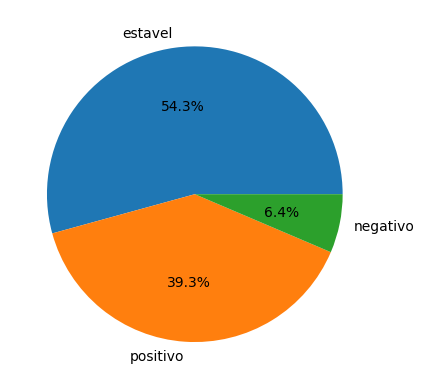

In [24]:
df_todos_os_anos_ian['delta_ian'].value_counts().plot.pie(autopct="%1.1f%%")

In [25]:
df_todos_os_anos_ian_estavel = df_todos_os_anos_ian.query(''' delta_ian == "estavel" ''')

*Os alunos que mantiveram o IAN estável nos três anos não pertencem a faixa mais negativa do indicador, com 2 anos ou mais de defasagem*

In [26]:
df_todos_os_anos_ian_estavel['ian_2024'].value_counts()

ian_2024
5.0     129
10.0    125
Name: count, dtype: int64

### 2. Desempenho acadêmico (IDA): O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos? 

In [27]:
df_todos_os_anos_ida = df_pivot[df_pivot.loc[:, ["ida_2022", "ida_2023", "ida_2024"]].fillna(False).all(axis=1)]

In [28]:
df_todos_os_anos_ida.shape

(429, 188)

In [29]:
df_todos_os_anos_ida['delta_ida'] = np.where(
    df_todos_os_anos_ida['ida_2024'] - df_todos_os_anos_ida['ida_2022'] > 0, 'positivo', 
    np.where(df_todos_os_anos_ida['ida_2024'] - df_todos_os_anos_ida['ida_2022'] < 0, 'negativo', 'estavel')
)

In [30]:
df_todos_os_anos_ida.loc[:, ["ida_2022", "ida_2023", "ida_2024", "delta_ida"]].head()

,ida_2022,ida_2023,ida_2024,delta_ida
35,7.3,7.1,9.166667,positivo
68,7.4,7.3,5.666667,negativo
79,4.6,7.0,4.666667,positivo
113,6.7,7.5,8.500000,positivo
124,8.0,6.0,8.333333,positivo


<Axes: >

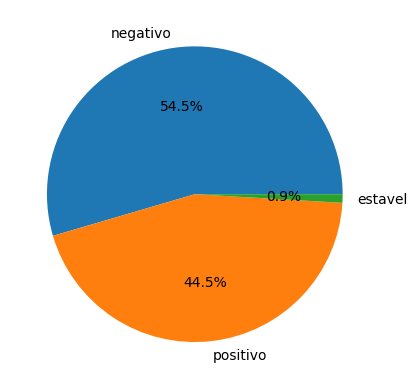

In [31]:
df_todos_os_anos_ida['delta_ida'].value_counts().plot.pie(autopct="%1.1f%%")

In [32]:
df_todos_os_anos_ida[["ida_2022", "ida_2023", "ida_2024"]].mean()

ida_2022    6.680653
ida_2023    6.785781
ida_2024    6.294172
dtype: float64

### 3. Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)? 

In [33]:
df_todos_os_anos_ieg = df_pivot[df_pivot.loc[:, ["ieg_2022", "ieg_2023", "ieg_2024"]].fillna(False).all(axis=1)]

In [34]:
df_todos_os_anos_ieg.shape

(432, 188)

In [35]:

colunas_analise_ieg = [
    "ieg_2022",
    "ieg_2023",
    "ieg_2024",
    "ida_2022",
    "ida_2023",
    "ida_2024",
    "ipv_2022",
    "ipv_2023",
    "ipv_2024"
]

In [36]:
df_todos_os_anos_ieg[colunas_analise_ieg].head()

,ieg_2022,ieg_2023,ieg_2024,ida_2022,ida_2023,ida_2024,ipv_2022,ipv_2023,ipv_2024
35,8.7,9.2,9.603175,7.3,7.1,9.166667,7.708,8.0900,8.872
68,8.0,9.1,8.761905,7.4,7.3,5.666667,8.375,7.5075,7.872
79,6.4,8.5,7.994987,4.6,7.0,4.666667,6.500,7.5875,6.964
113,9.7,8.6,9.696970,6.7,7.5,8.500000,8.000,8.2975,8.504
124,9.4,8.7,9.488636,8.0,6.0,8.333333,8.667,8.0875,8.740


In [37]:
df_ieg_2024 = df_todos_os_anos_ieg[filter(lambda col: "2024" in col, colunas_analise_ieg)]

In [38]:
df_ieg_2024.corr()

,ieg_2024,ida_2024,ipv_2024
ieg_2024,1.000000,0.565379,0.649079
ida_2024,0.565379,1.000000,0.638937
ipv_2024,0.649079,0.638937,1.000000


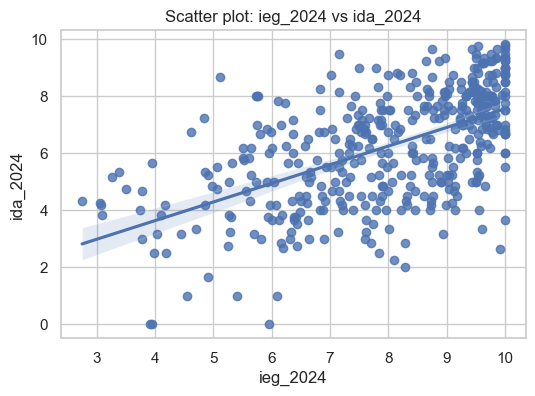

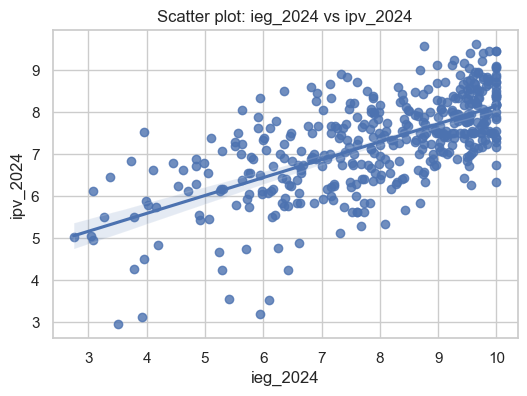

In [39]:
# estilo opcional
sns.set(style="whitegrid")

# Scatter: ieg_2024 x ida_2024
plt.figure(figsize=(6, 4))
sns.regplot(data=df_ieg_2024, x="ieg_2024", y="ida_2024")
plt.title("Scatter plot: ieg_2024 vs ida_2024")
plt.show()

# Scatter: ieg_2024 x ipv_2024
plt.figure(figsize=(6, 4))
sns.regplot(data=df_ieg_2024, x="ieg_2024", y="ipv_2024")
plt.title("Scatter plot: ieg_2024 vs ipv_2024")
plt.show()

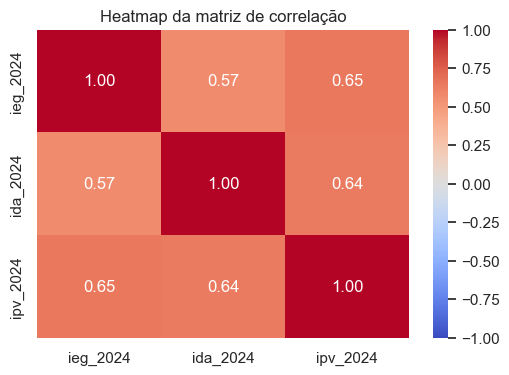

In [40]:
# matriz de correlação
corr = df_ieg_2024[["ieg_2024", "ida_2024", "ipv_2024"]].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr,
    annot=True,        # mostra os valores
    fmt=".2f",         # casas decimais
    cmap="coolwarm",   # esquema de cores
    vmin=-1,
    vmax=1
)

plt.title("Heatmap da matriz de correlação")
plt.show()

*IDA e IPV possuem correlação moderada com o IEG (0,56 e 0,64 respectivamente)*

- IDA = Indicador de desempenho acadêmico: Notas de provas e média geral universitária
- IPV = Indicador do ponto de virada: Questionário individual de avaliação dos pedagogos e professores (Avaliação psicopedagógica, subjetivo?)
- **IEG** = Indicador de engajamento: Registro de entrega de lição de cada e voluntariado

### 4. Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

- **IAA**: Indicador de autoavaliação
- IDA: Indicador de desenvolvimento acadêmico - (Nota Matemática + Nota Português + Nota Inglês) / 3
- IEG: Indicador de engajamento - Soma das pontuações das tarefas realizadas e registradas / Número de tarefas

In [41]:
df_iaa_todos_anos = df_pivot[df_pivot.loc[:,df_pivot.columns.str.contains("iaa")].fillna(False).all(axis=1)]

In [42]:
df_iaa_todos_anos.shape

(338, 188)

In [43]:
df_iaa_todos_anos.head()

,ra,fase_2022,fase_2023,fase_2024,turma_2022,turma_2023,turma_2024,nome_2022,nome_2023,nome_2024,...,escola_2022,escola_2023,escola_2024,ativo/inativo_2022,ativo/inativo_2023,ativo/inativo_2024,ativo/inativo_1_2022,ativo/inativo_1_2023,ativo/inativo_1_2024,fase_2024
35,RA-103,4,FASE 5,5A,A,5A,5A,Aluno-103,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,5
68,RA-106,4,FASE 5,6A,A,5A,6A,Aluno-106,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,6
113,RA-110,4,FASE 5,5A,A,5A,5A,Aluno-110,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,5
124,RA-111,4,FASE 5,5B,A,5A,5B,Aluno-111,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,5
135,RA-112,4,FASE 5,6A,A,5A,6A,Aluno-112,NaN,NaN,...,NaN,NaN,Colégio Arco Íris Evolução,NaN,NaN,Cursando,NaN,NaN,Cursando,6


In [44]:
df_iaa_todos_anos_cols_indicadores = df_iaa_todos_anos.loc[:,df_iaa_todos_anos.columns.str.contains(r"^iaa_|^ida_|^ieg_", regex=True)]

In [45]:
df_iaa_todos_anos_cols_indicadores.describe()

,iaa_2022,iaa_2023,iaa_2024,ieg_2022,ieg_2023,ieg_2024,ida_2022,ida_2023,ida_2024
count,338.000000,338.000000,338.000000,338.000000,333.000000,338.000000,338.000000,333.000000,338.000000
mean,8.788462,8.571302,8.680322,8.655030,8.823423,8.116524,6.826923,6.811712,6.380671
std,0.907184,1.193816,0.925169,1.138895,1.022661,1.835898,1.778244,1.421314,2.060098
min,5.200000,1.700000,4.584000,3.500000,4.100000,0.000000,1.300000,2.200000,0.000000
25%,8.300000,7.900000,8.002000,8.200000,8.300000,7.299901,5.700000,6.000000,5.000000
50%,9.000000,8.800000,8.751000,8.900000,9.100000,8.696197,7.100000,6.900000,6.750000
75%,9.500000,9.500000,9.418500,9.400000,9.600000,9.543571,8.100000,7.900000,8.000000
max,10.000000,10.000000,10.002000,10.000000,10.000000,10.000000,9.900000,9.700000,9.833333


In [46]:
df_iaa_todos_anos_cols_indicadores.loc[:, df_iaa_todos_anos_cols_indicadores.columns.str.contains('2022')].corr()

,iaa_2022,ieg_2022,ida_2022
iaa_2022,1.000000,0.050360,0.117641
ieg_2022,0.050360,1.000000,0.409565
ida_2022,0.117641,0.409565,1.000000


In [47]:
'''
delta < 0 -> subestima
delta > 0 -> superestima
'''

df_iaa_todos_anos_cols_indicadores['delta_iaa_ieg_2022'] = df_iaa_todos_anos_cols_indicadores['iaa_2022'] - df_iaa_todos_anos_cols_indicadores['ieg_2022']
df_iaa_todos_anos_cols_indicadores['delta_iaa_ida_2022'] = df_iaa_todos_anos_cols_indicadores['iaa_2022'] - df_iaa_todos_anos_cols_indicadores['ida_2022']

df_iaa_todos_anos_cols_indicadores['delta_iaa_ieg_2023'] = df_iaa_todos_anos_cols_indicadores['iaa_2023'] - df_iaa_todos_anos_cols_indicadores['ieg_2023']
df_iaa_todos_anos_cols_indicadores['delta_iaa_ida_2023'] = df_iaa_todos_anos_cols_indicadores['iaa_2023'] - df_iaa_todos_anos_cols_indicadores['ida_2023']

df_iaa_todos_anos_cols_indicadores['delta_iaa_ieg_2024'] = df_iaa_todos_anos_cols_indicadores['iaa_2024'] - df_iaa_todos_anos_cols_indicadores['ieg_2024']
df_iaa_todos_anos_cols_indicadores['delta_iaa_ida_2024'] = df_iaa_todos_anos_cols_indicadores['iaa_2024'] - df_iaa_todos_anos_cols_indicadores['ida_2024']

In [48]:
display(df_iaa_todos_anos_cols_indicadores.query("iaa_2022 > 0 and ieg_2022 > 0")['delta_iaa_ieg_2022'].describe())
display(df_iaa_todos_anos_cols_indicadores.query("iaa_2022 > 0 and ida_2022 > 0")['delta_iaa_ida_2022'].describe())

count    338.000000
mean       0.133432
std        1.419859
min       -4.000000
25%       -0.800000
50%        0.100000
75%        0.900000
max        6.000000
Name: delta_iaa_ieg_2022, dtype: float64

count    338.000000
mean       1.961538
std        1.898836
min       -2.700000
25%        0.500000
50%        1.800000
75%        3.000000
max        7.700000
Name: delta_iaa_ida_2022, dtype: float64

In [49]:
display(df_iaa_todos_anos_cols_indicadores['delta_iaa_ieg_2023'].describe())
display(df_iaa_todos_anos_cols_indicadores['delta_iaa_ida_2023'].describe())

display(df_iaa_todos_anos_cols_indicadores.query("iaa_2023 > 0 and ieg_2023 > 0")['delta_iaa_ieg_2023'].describe())
display(df_iaa_todos_anos_cols_indicadores.query("iaa_2023 > 0 and ida_2023 > 0")['delta_iaa_ida_2023'].describe())

count    333.000000
mean      -0.245946
std        1.528078
min       -6.400000
25%       -1.200000
50%       -0.200000
75%        0.500000
max        5.900000
Name: delta_iaa_ieg_2023, dtype: float64

count    333.000000
mean       1.765766
std        1.782740
min       -5.500000
25%        0.600000
50%        1.700000
75%        2.800000
max        6.900000
Name: delta_iaa_ida_2023, dtype: float64

count    333.000000
mean      -0.245946
std        1.528078
min       -6.400000
25%       -1.200000
50%       -0.200000
75%        0.500000
max        5.900000
Name: delta_iaa_ieg_2023, dtype: float64

count    333.000000
mean       1.765766
std        1.782740
min       -5.500000
25%        0.600000
50%        1.700000
75%        2.800000
max        6.900000
Name: delta_iaa_ida_2023, dtype: float64

In [50]:
display(df_iaa_todos_anos_cols_indicadores['delta_iaa_ieg_2024'].describe())
display(df_iaa_todos_anos_cols_indicadores['delta_iaa_ida_2024'].describe())

display(df_iaa_todos_anos_cols_indicadores.query("iaa_2024 > 0 and ieg_2024 > 0")['delta_iaa_ieg_2024'].describe())
display(df_iaa_todos_anos_cols_indicadores.query("iaa_2024 > 0 and ida_2024 > 0")['delta_iaa_ida_2024'].describe())

count    338.000000
mean       0.563798
std        1.871341
min       -3.037333
25%       -0.748000
50%        0.140947
75%        1.499799
max        9.168000
Name: delta_iaa_ieg_2024, dtype: float64

count    338.000000
mean       2.299652
std        2.140222
min       -2.248000
25%        0.752000
50%        2.002000
75%        3.563500
max        9.168000
Name: delta_iaa_ida_2024, dtype: float64

count    335.000000
mean       0.490480
std        1.710225
min       -3.037333
25%       -0.753952
50%        0.130364
75%        1.444443
max        7.251482
Name: delta_iaa_ieg_2024, dtype: float64

count    333.000000
mean       2.206539
std        2.014683
min       -2.248000
25%        0.752000
50%        2.002000
75%        3.502000
max        8.585000
Name: delta_iaa_ida_2024, dtype: float64

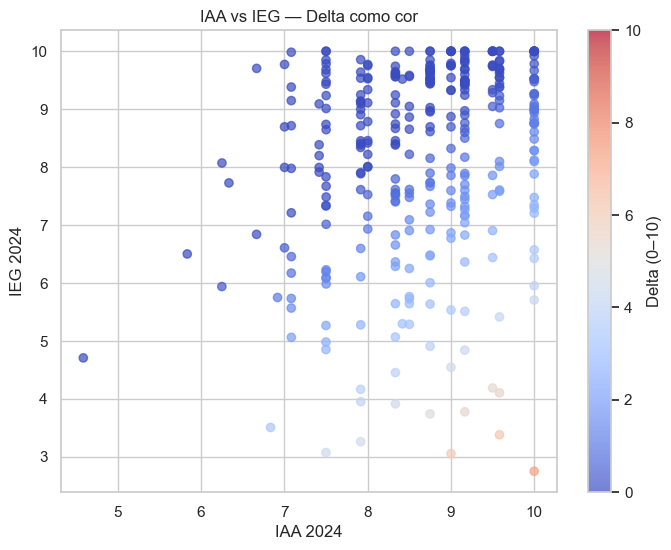

In [53]:
df_plot = df_iaa_todos_anos_cols_indicadores.query("iaa_2024 > 0 and ieg_2024 > 0")[['iaa_2024', 'ieg_2024', 'delta_iaa_ieg_2024']]

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df_plot['iaa_2024'],
    df_plot['ieg_2024'],
    c=df_plot['delta_iaa_ieg_2024'],
    cmap='coolwarm',   # azul → vermelho
    vmin=0,            # azul fixo
    vmax=10,           # vermelho fixo
    alpha=0.7
)

plt.colorbar(scatter, label='Delta (0–10)')
plt.xlabel('IAA 2024')
plt.ylabel('IEG 2024')
plt.title('IAA vs IEG — Delta como cor')

plt.show()

Text(0.5, 1.0, 'IAA vs IDA — Delta como cor')

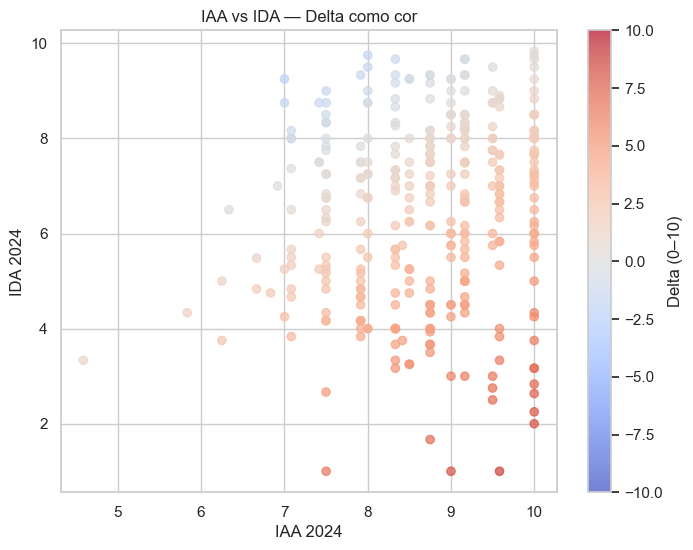

In [55]:
df_plot = df_iaa_todos_anos_cols_indicadores.query("iaa_2024 > 0 and ida_2024 > 0")[['iaa_2024', 'ida_2024', 'delta_iaa_ida_2024']]
                                                                                    

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df_plot['iaa_2024'],
    df_plot['ida_2024'],
    c=df_plot['delta_iaa_ida_2024'],
    cmap='coolwarm',   # azul → vermelho
    vmin=-10,            # azul fixo
    vmax=10,           # vermelho fixo
    alpha=0.7
)

plt.colorbar(scatter, label='Delta (0–10)')
plt.xlabel('IAA 2024')
plt.ylabel('IDA 2024')
plt.title('IAA vs IDA — Delta como cor')

In [52]:
df_iaa_todos_anos_cols_indicadores.sort_values(by='delta_iaa_ieg_2024', ascending=False).query("iaa_2024 > 0 and ieg_2024 > 0").head()

,iaa_2022,iaa_2023,iaa_2024,ieg_2022,ieg_2023,ieg_2024,ida_2022,ida_2023,ida_2024,delta_iaa_ieg_2022,delta_iaa_ida_2022,delta_iaa_ieg_2023,delta_iaa_ida_2023,delta_iaa_ieg_2024,delta_iaa_ida_2024
1168,9.5,7.4,10.002,8.1,8.1,2.750518,4.4,3.9,4.333333,1.4,5.1,-0.7,3.5,7.251482,5.668667
1247,7.4,9.0,9.585,7.6,9.2,3.380451,1.3,6.5,5.333333,-0.2,6.1,-0.2,2.5,6.204549,4.251667
1227,7.8,10.0,9.002,9.6,7.5,3.054348,6.3,6.2,4.250000,-1.8,1.5,2.5,3.8,5.947652,4.752000
545,9.2,8.8,9.585,6.5,4.2,4.104379,5.0,4.7,3.833333,2.7,4.2,4.6,4.1,5.480621,5.751667
1171,9.0,7.8,9.168,8.5,9.4,3.776398,4.3,6.0,3.000000,0.5,4.7,-1.6,1.8,5.391602,6.168000
